In [4]:
# Import libraries for data manipulation and visualization.
# pandas: load and process time series; matplotlib: plot GDP and diagnostics.
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load US quarterly GDP from CSV and set the index to a quarterly period index.
# Print the first rows and summary statistics to inspect the series.
gdp = pd.read_csv('GDP.csv', index_col='observation_date', parse_dates=True)
gdp.index = pd.PeriodIndex(gdp.index, freq='Q')  # Set quarterly frequency
print(gdp.head())
print(gdp.describe())

                      GDP
observation_date         
1947Q1            243.164
1947Q2            245.968
1947Q3            249.585
1947Q4            259.745
1948Q1            265.742
                GDP
count    308.000000
mean    7171.903451
std     7425.232231
min      243.164000
25%      802.669250
50%     4340.830000
75%    12360.783750
max    28424.722000


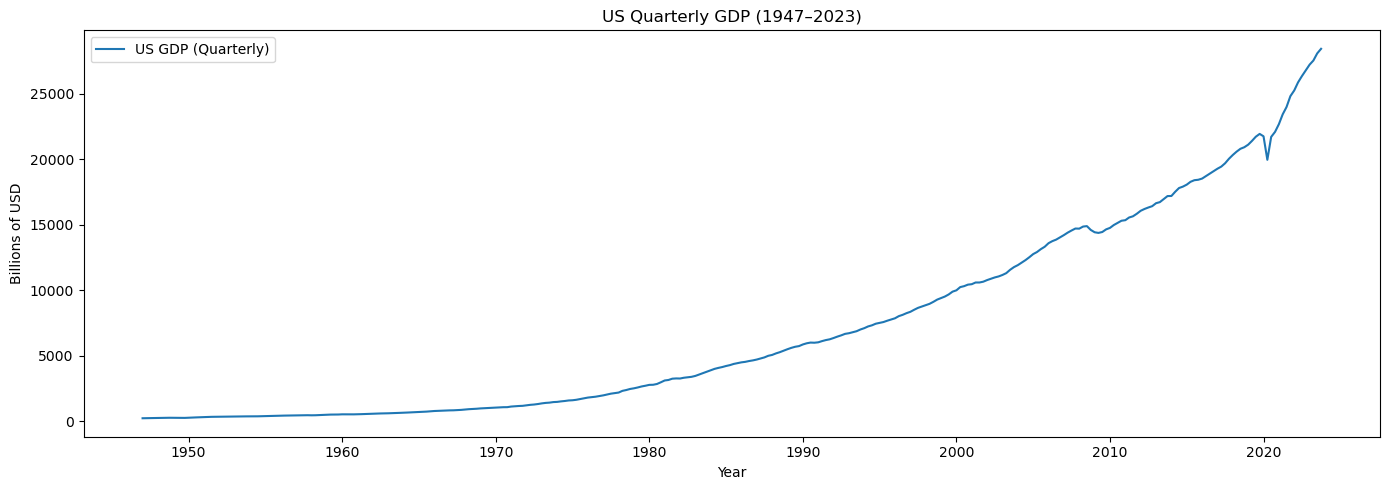

In [7]:
# Convert period index to timestamps for plotting.
# Plot the full US quarterly GDP time series (1947–2023) in billions of USD.
gdp.index = gdp.index.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(gdp, label='US GDP (Quarterly)')
plt.title('US Quarterly GDP (1947–2023)')
plt.xlabel('Year')
plt.ylabel('Billions of USD')
plt.legend()
plt.tight_layout()
plt.show()

GDP grows exponentially over time — the variance increases as the level increases. This means I should use multiplicative decomposition

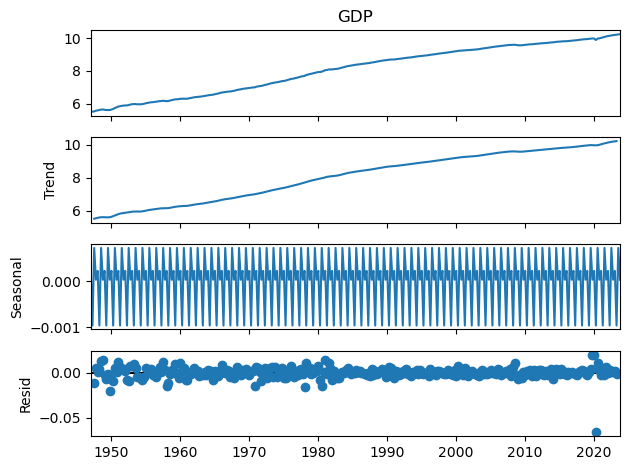

In [8]:
# Decompose GDP into trend, seasonal, and residual components.
# Use log-transformed GDP and additive model with quarterly period (4); plot all components.
from statsmodels.tsa.seasonal import seasonal_decompose

# Log-transform first for cleaner decomposition
import numpy as np
gdp_log = np.log(gdp['GDP'])

decomp = seasonal_decompose(gdp_log, model='additive', period=4)
decomp.plot()
plt.tight_layout()
plt.show()

In [9]:
# Run Augmented Dickey-Fuller test on raw GDP to check for stationarity.
# Print ADF statistic, p-value, and critical values; p > 0.05 indicates non-stationary series.
from statsmodels.tsa.stattools import adfuller

result = adfuller(gdp['GDP'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Critical Values: {result[4]}')

# Interpret: if p > 0.05, series is non-stationary

ADF Statistic: 8.8164
p-value: 1.0000
Critical Values: {'1%': np.float64(-3.4519023023726696), '5%': np.float64(-2.8710320399170537), '10%': np.float64(-2.57182745012602)}


ADF after log + first diff: p = 0.0000


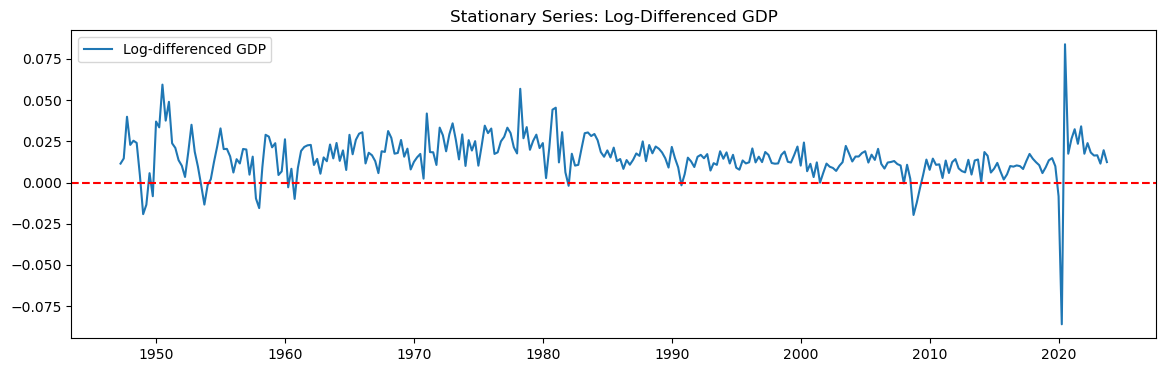

In [11]:
# Make the series stationary: log transform (stabilize variance) then first difference (remove trend).
# Re-run ADF on differenced series; plot the stationary log-differenced GDP.
# Step 1: Log transform (stabilizes variance)
gdp_log = np.log(gdp['GDP'])

# Step 2: First difference (removes trend) → d = 1
gdp_diff = gdp_log.diff().dropna()

# Re-test ADF
result2 = adfuller(gdp_diff)
print(f'ADF after log + first diff: p = {result2[1]:.4f}')

# If still non-stationary, second difference → d = 2
# Usually d=1 is enough for GDP

plt.figure(figsize=(14,4))
plt.plot(gdp_diff, label='Log-differenced GDP')
plt.axhline(0, color='red', linestyle='--')
plt.title('Stationary Series: Log-Differenced GDP')
plt.legend()
plt.show()

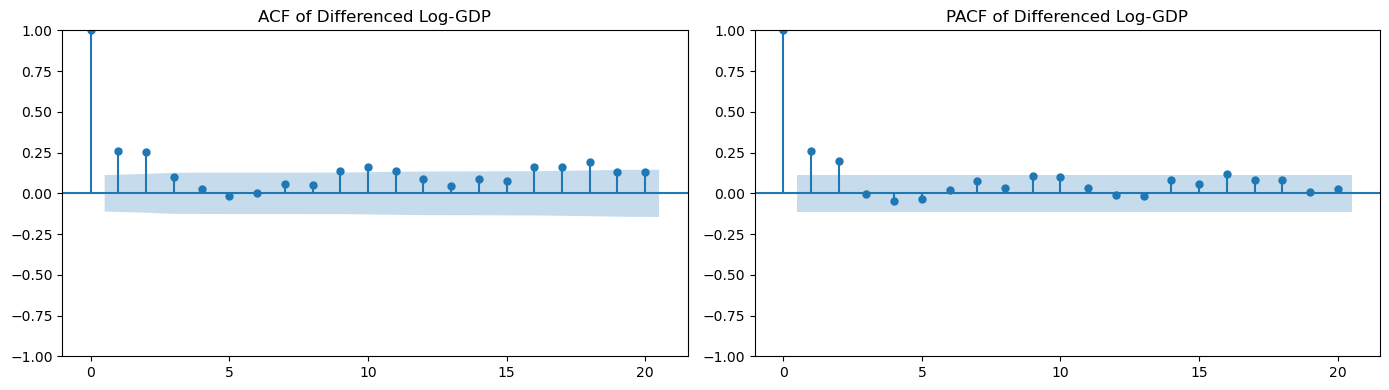

In [12]:
# Plot ACF and PACF of the stationary (log-differenced) GDP series.
# Used to choose ARIMA orders p and q (e.g., PACF cutoff → p, ACF cutoff → q).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(gdp_diff, lags=20, ax=axes[0], title='ACF of Differenced Log-GDP')
plot_pacf(gdp_diff, lags=20, ax=axes[1], title='PACF of Differenced Log-GDP')
plt.tight_layout()
plt.show()

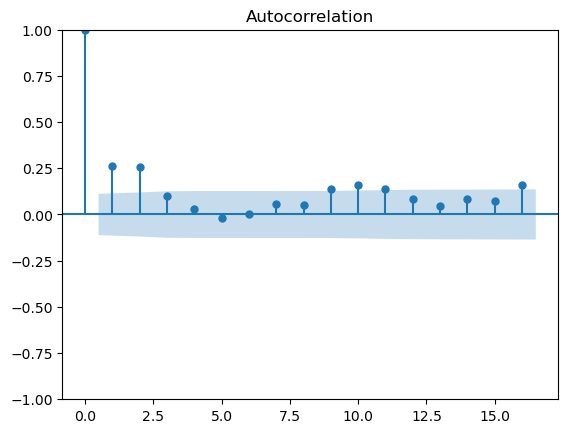

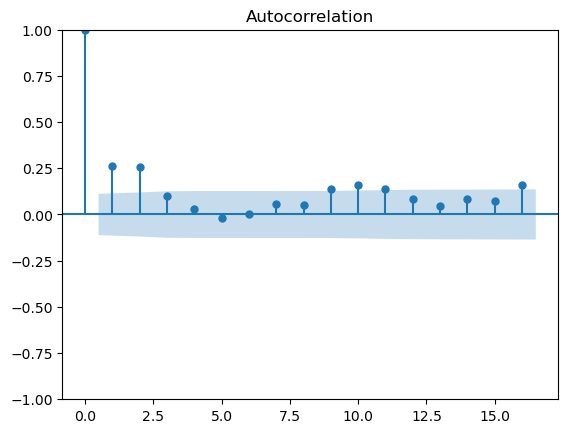

In [13]:
# Plot ACF of differenced GDP with 16 lags (compact view for seasonal/order checks).
plot_acf(gdp_diff, lags=16)

In [14]:
# Split GDP into 80% training and 20% test for out-of-sample evaluation.
# Print train/test sizes and date ranges.
n = len(gdp)
split = int(n * 0.80)
train = gdp['GDP'][:split]
test = gdp['GDP'][split:]
print(f"Train size: {len(train)} quarters")
print(f"Test size:  {len(test)} quarters")
print(f"Training period: {train.index[0]} to {train.index[-1]}")
print(f"Test period:     {test.index[0]} to {test.index[-1]}")

Train size: 246 quarters
Test size:  62 quarters
Training period: 1947-01-01 00:00:00 to 2008-04-01 00:00:00
Test period:     2008-07-01 00:00:00 to 2023-10-01 00:00:00


In [15]:
# Fit SARIMA(1,1,1)(1,1,0,4) on log-transformed training GDP.
# Seasonal order 4 captures quarterly pattern; print fitted model summary.
from statsmodels.tsa.statespace.sarimax import SARIMAX
log_train = np.log(train)

model = SARIMAX(log_train,
                order=(1, 1, 1),           # p, d, q
                seasonal_order=(1, 1, 0, 4), # P, D, Q, s
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                GDP   No. Observations:                  246
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 4)   Log Likelihood                 714.293
Date:                            Mon, 23 Feb 2026   AIC                          -1420.585
Time:                                    23:17:09   BIC                          -1406.730
Sample:                                01-01-1947   HQIC                         -1415.000
                                     - 04-01-2008                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4647      0.132      3.531      0.000       0.207       0.723
ma.L1         -0.0886      0.157   

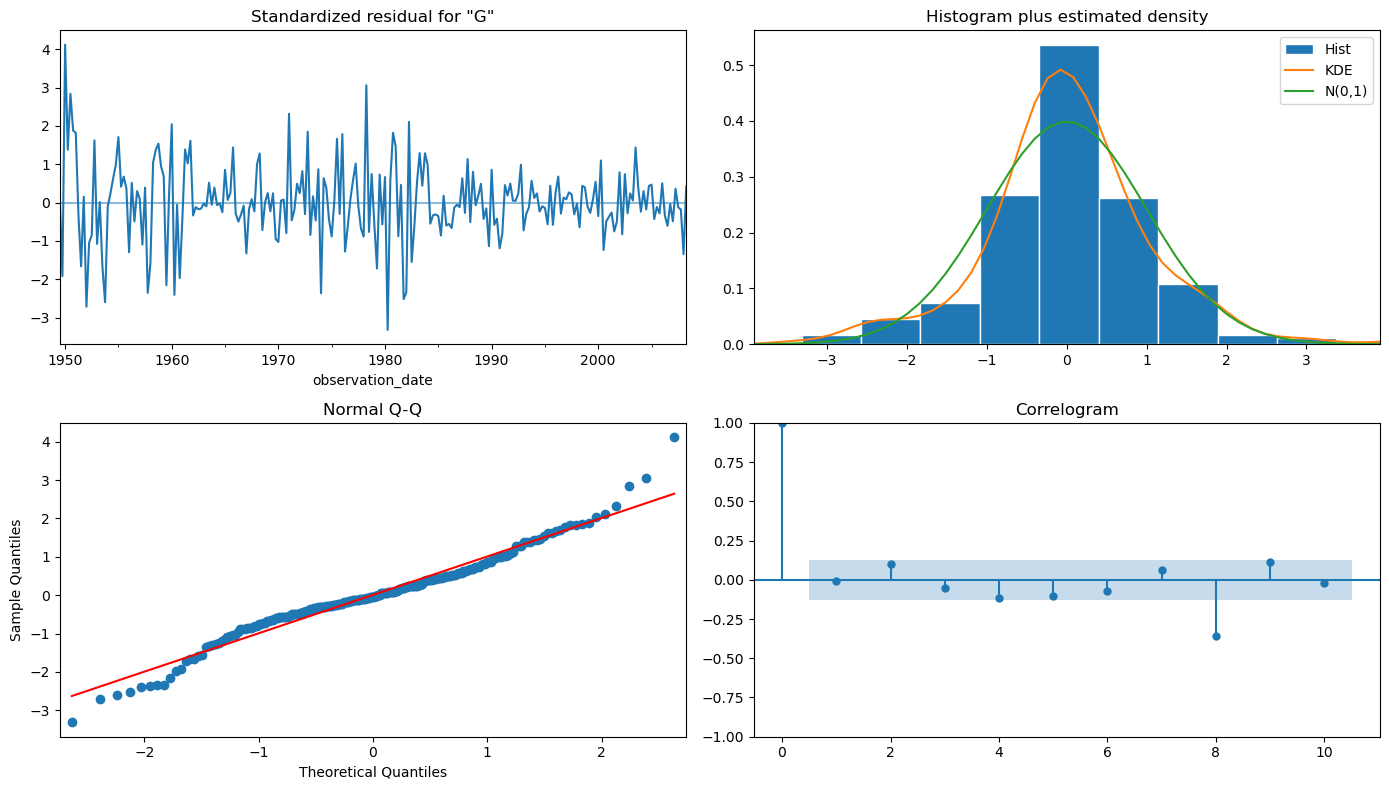

In [16]:
# Plot SARIMA residual diagnostics: standardized residuals, histogram, Q-Q, and correlogram.
# Used to check that residuals look like white noise.
results.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()

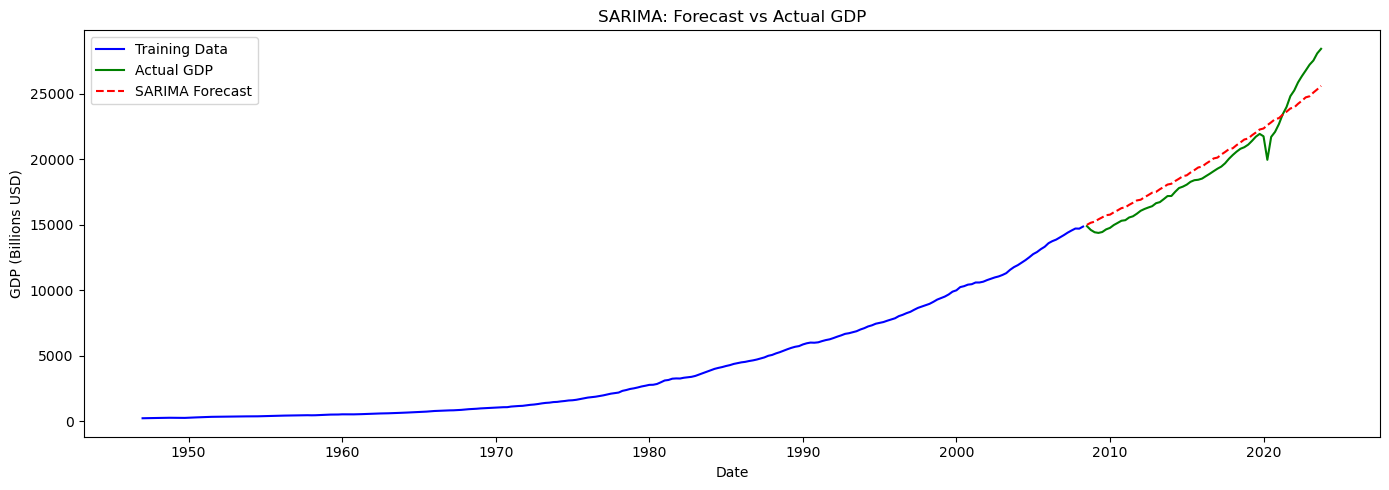

In [20]:
# Generate SARIMA forecast for the test period (in log space), then exp back to levels.
# Plot training data, actual test GDP, and forecast for comparison.
forecast_log = results.forecast(steps=len(test))
forecast = np.exp(forecast_log)
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual GDP', color='green')
plt.plot(test.index, forecast.values, 
         label='SARIMA Forecast', linestyle='--', color='red')
plt.title('SARIMA: Forecast vs Actual GDP')
plt.xlabel('Date')
plt.ylabel('GDP (Billions USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Evaluate forecast accuracy: compute RMSE, MAE, and MAPE vs actual test GDP.
# Lower values indicate better fit.
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

RMSE: 1153.42
MAE:  992.00
MAPE: 5.08%
